In [ ]:
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 18.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.


In [ ]:
import os
import glob
import cv2
import math
import numpy as np
import seaborn as sns
import mediapipe as mp
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from google.colab import files
from collections import Counter, defaultdict
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_ROOT = "/content/drive/MyDrive/Faintset/Faintset_Splitted"

print("Dataset path set to:", DATA_ROOT)
print("Subfolders:", os.listdir(DATA_ROOT))

Dataset path set to: /content/drive/MyDrive/Faintset/Faintset_Splitted
Subfolders: ['test', 'val', 'train']


In [ ]:
def list_videos(split):
    root = os.path.join(DATA_ROOT, split)
    files = []

    for label in ["Faint", "Normal"]:
        label_dir = os.path.join(root, label)
        if not os.path.exists(label_dir):
            continue

        for f in os.listdir(label_dir):
            name = os.path.splitext(f)[0].lower()
            files.append(label + "/" + name)   # include class

    return set(files)


train = list_videos("train")
val   = list_videos("val")
test  = list_videos("test")

print("Train ∩ Val :", len(train & val))
print("Train ∩ Test:", len(train & test))
print("Val ∩ Test  :", len(val & test))


Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


Faint: [228, 29, 28]
Normal: [228, 28, 29]


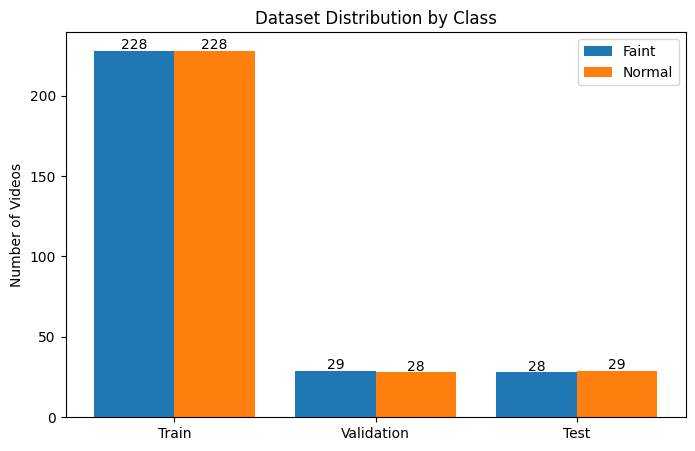

In [ ]:
def count_videos(split, label):
    path = os.path.join(DATA_ROOT, split, label)
    return len(os.listdir(path))

splits = ["train","val","test"]

faint_counts = [count_videos(s,"Faint") for s in splits]
normal_counts = [count_videos(s,"Normal") for s in splits]

print("Faint:", faint_counts)
print("Normal:", normal_counts)

x = range(len(splits))

plt.figure(figsize=(8,5))

plt.bar([i-0.2 for i in x], faint_counts, width=0.4, label="Faint")
plt.bar([i+0.2 for i in x], normal_counts, width=0.4, label="Normal")

plt.xticks(x, ["Train","Validation","Test"])
plt.ylabel("Number of Videos")
plt.title("Dataset Distribution by Class")
plt.legend()

# show numbers on bars
for i,v in enumerate(faint_counts):
    plt.text(i-0.2, v+1, str(v), ha='center')

for i,v in enumerate(normal_counts):
    plt.text(i+0.2, v+1, str(v), ha='center')

plt.show()

In [ ]:
KEYPOINT_ROOT = "/content/drive/MyDrive/Keypoints"
WINDOW_SIZE = 15

In [ ]:
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=2,
    smooth_landmarks=True,
    enable_segmentation=False,
    min_detection_confidence=0.3,
    min_tracking_confidence=0.3
)

In [ ]:
def extract_keypoints_from_video(video_path, frame_skip=2):
    pose.reset()

    cap = cv2.VideoCapture(str(os.path.abspath(video_path)))
    keypoints_list = []
    frame_count = 0
    detected_frames = 0

    last_valid_keypoints = None
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1
        if frame_count % frame_skip != 0:
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(frame_rgb)

        if results.pose_landmarks:
          detected_frames += 1
          landmarks = results.pose_landmarks.landmark
          keypoints = []
          for lm in landmarks:
              keypoints.append(lm.x)
              keypoints.append(lm.y)

          last_valid_keypoints = keypoints
          keypoints_list.append(keypoints)

        else:
          if last_valid_keypoints is not None:
              keypoints_list.append(last_valid_keypoints)
          else:
              keypoints_list.append(np.zeros(66))

    cap.release()
    print(f"{os.path.basename(video_path)} → {detected_frames}/{frame_count} detected")

    return np.array(keypoints_list)

In [ ]:
def extract_split(split_name):
    split_path = os.path.join(DATA_ROOT, split_name)
    save_split = os.path.join(KEYPOINT_ROOT, split_name)

    print(f"\nEXTRACTING {split_name.upper()}")

    for label in ["Faint", "Normal"]:
        label_path = os.path.join(split_path, label)
        save_label = os.path.join(save_split, label)

        os.makedirs(save_label, exist_ok=True)

        videos = sorted(glob.glob(os.path.join(label_path, "*.mp4")))
        print(f"{label}: {len(videos)} videos")

        for video in videos:
            keypoints = extract_keypoints_from_video(video)

            name = os.path.splitext(os.path.basename(video))[0]
            save_file = os.path.join(save_label, name + ".npy")

            np.save(save_file, keypoints)


extract_split("train")
extract_split("val")
extract_split("test")

print("\nALL KEYPOINTS SAVED.")


EXTRACTING TRAIN
Faint: 228 videos


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Faint-1.mp4 → 42/84 detected
Faint-10.mp4 → 33/67 detected
Faint-100.mp4 → 133/266 detected
Faint-101.mp4 → 105/211 detected
Faint-102.mp4 → 88/187 detected
Faint-103.mp4 → 42/96 detected
Faint-105.mp4 → 101/204 detected
Faint-106.mp4 → 65/131 detected
Faint-107.mp4 → 61/123 detected
Faint-108.mp4 → 88/178 detected
Faint-109.mp4 → 170/340 detected
Faint-11.mp4 → 89/178 detected
Faint-113.mp4 → 101/203 detected
Faint-114.mp4 → 67/134 detected
Faint-115.mp4 → 76/153 detected
Faint-116.mp4 → 70/140 detected
Faint-117.mp4 → 152/316 detected
Faint-12.mp4 → 69/139 detected
Faint-120.mp4 → 147/295 detected
Faint-121.mp4 → 173/346 detected
Faint-122.mp4 → 52/105 detected
Faint-123.mp4 → 67/138 detected
Faint-125.mp4 → 95/191 detected
Faint-126.mp4 → 53/106 detected
Faint-127.mp4 → 37/75 detected
Faint-129.mp4 → 10/71 detected
Faint-13.mp4 → 86/174 detected
Faint-130.mp4 → 16/61 detected
Faint-131.mp4 → 29/58 detected
Faint-132.mp4 → 25/78 detected
Faint-133.mp4 → 131/262 detected
Faint-134.mp4

In [ ]:
def load_npy_split(split_name):
    X, y = [], []

    split_path = os.path.join(KEYPOINT_ROOT, split_name)
    print(f"\nLoading {split_name}")

    for label in ["Faint", "Normal"]:
        label_path = os.path.join(split_path, label)
        files = sorted(os.listdir(label_path))

        print(label, ":", len(files), "files")

        for f in files:
            seq = np.load(os.path.join(label_path, f))

            if len(seq) < WINDOW_SIZE:
                continue

            for i in range(0, len(seq) - WINDOW_SIZE + 1, WINDOW_SIZE):
                X.append(seq[i:i+WINDOW_SIZE])
                y.append(0 if label == "Faint" else 1)

    return np.array(X), np.array(y)


X_train, y_train = load_npy_split("train")
X_val,   y_val   = load_npy_split("val")
X_test,  y_test  = load_npy_split("test")

print("\nShapes:")
print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Loading train
Faint : 228 files
Normal : 228 files

Loading val
Faint : 29 files
Normal : 28 files

Loading test
Faint : 28 files
Normal : 29 files

Shapes:
Train: (3290, 15, 66)
Val  : (368, 15, 66)
Test : (410, 15, 66)


In [ ]:
# Build the CNN-BiLSTM Model
model = Sequential([
    Conv1D(
        filters=32,
        kernel_size=3,
        activation='relu',
        padding='same',
        input_shape=(WINDOW_SIZE, 66)
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Bidirectional(
        LSTM(
            64,
            return_sequences=True)
    ),

    Dropout(0.5),
    Bidirectional(
        LSTM(
            32,
            return_sequences=False)
    ),

    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the Model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 15, 32)         │         6,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 7, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 3, 128)         │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,370 (478.01 KB)

 Trainable params: 122,178 (477.26 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Train the Model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    verbose=1
)

Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7263 - loss: 0.5285 - val_accuracy: 0.7636 - val_loss: 0.4534
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8418 - loss: 0.3792 - val_accuracy: 0.7609 - val_loss: 0.4755
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8557 - loss: 0.3255 - val_accuracy: 0.8207 - val_loss: 0.3993
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8527 - loss: 0.3406 - val_accuracy: 0.8016 - val_loss: 0.4727
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8925 - loss: 0.2643 - val_accuracy: 0.8478 - val_loss: 0.4461
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8707 - loss: 0.2939 - val_accuracy: 0.8288 - val_loss: 0.4213
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8547 - loss: 0.3424 - val_accuracy: 0.8207 - val_loss: 0.4071
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8672 - loss: 0.3094 - val_acc

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Validation Accuracy: 88.32 %

Classification Report:
              precision    recall  f1-score   support

       Faint       0.88      0.73      0.80       116
      Normal       0.89      0.95      0.92       252

    accuracy                           0.88       368
   macro avg       0.88      0.84      0.86       368
weighted avg       0.88      0.88      0.88       368



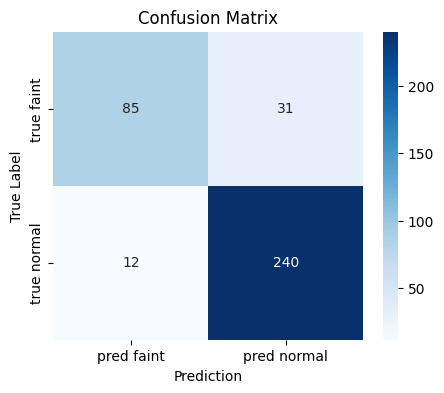

In [ ]:
# Predict on the validation set
y_pred = np.argmax(model.predict(X_val), axis=1)

# Calculate overall accuracy score
acc = accuracy_score(y_val, y_pred)
print("\nValidation Accuracy:", round(acc*100, 2), "%")

# Display precision, recall, and F1-score for each class
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=["Faint", "Normal"]))

# Compute the confusion matrix between actual and predicted labels
cm = confusion_matrix(y_val, y_pred)

# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
           xticklabels=["pred faint","pred normal"],
yticklabels=["true faint","true normal"]
)
plt.title("Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("True Label")
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Test Accuracy: 86.59 %

Classification report:
              precision    recall  f1-score   support

       Faint       0.91      0.60      0.72       120
      Normal       0.85      0.98      0.91       290

    accuracy                           0.87       410
   macro avg       0.88      0.79      0.82       410
weighted avg       0.87      0.87      0.86       410



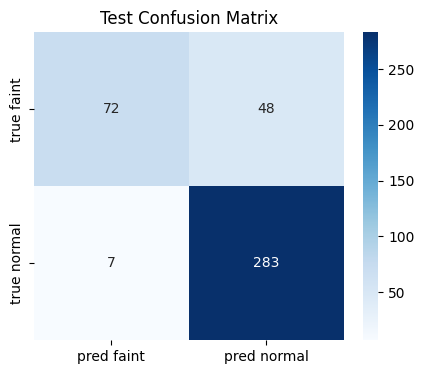

In [ ]:
# Predict on the test set
y_test_pred = np.argmax(model.predict(X_test), axis=1)

# Calculate overall accuracy score
print("\nTest Accuracy:", round(accuracy_score(y_test, y_test_pred)*100, 2), "%")

# Display precision, recall, and F1-score for each class
print("\nClassification report:")
print(classification_report(y_test, y_test_pred, target_names=["Faint","Normal"]))

# Compute the confusion matrix between actual and predicted labels
cm_test = confusion_matrix(y_test, y_test_pred)

# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=["pred faint","pred normal"],
yticklabels=["true faint","true normal"]
)
plt.title("Test Confusion Matrix")
plt.show()

In [ ]:
model.save("faint_detection_model.h5")

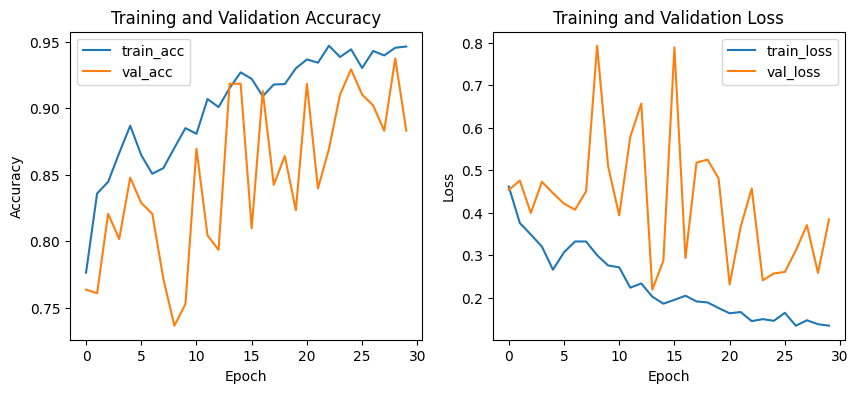

In [ ]:
# Plot Accuracy and Loss Curves
# Plot training vs validation accuracy and loss curves
plt.figure(figsize=(10,4))

# Plot accuracy curve
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss curve
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
model_path = "/content/faint_detection_model.h5"
model = load_model(model_path)
print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
def predict_and_save(video_path, model, output_path="predicted_output.mp4",
                     window_size=15, frame_skip=2):

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Error: cannot open video file.")
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    keypoints_buffer = []
    current_prediction = "Analyzing"
    frame_idx = 0
    last_valid_keypoints = None

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1
        if frame_idx % frame_skip != 0:
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(frame_rgb)

        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark
            keypoints = [coord for lm in landmarks for coord in (lm.x, lm.y)]
            last_valid_keypoints = keypoints
            keypoints_buffer.append(keypoints)
        else:
            if last_valid_keypoints is not None:
                keypoints_buffer.append(last_valid_keypoints)
            else:
                keypoints_buffer.append(np.zeros(66))

        if len(keypoints_buffer) == window_size:
            seq = np.array(keypoints_buffer).reshape(1, window_size, 66)
            pred = model.predict(seq, verbose=0)
            label_idx = np.argmax(pred)
            conf = np.max(pred)
            current_prediction = f"FAINT ({conf*100:.1f}%)" if label_idx == 0 else f"NORMAL ({conf*100:.1f}%)"
            keypoints_buffer = []

        color = (0, 0, 255) if "FAINT" in current_prediction else (0, 255, 0)
        cv2.putText(frame, current_prediction, (30, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3, cv2.LINE_AA)

        out.write(frame)

    cap.release()
    out.release()
    print(f"Output video saved as: {output_path}")

In [ ]:
test  = "/content/drive/MyDrive/Faintset/Faint.mp4"
output_video = "predicted_output(FAINT).mp4"

predict_and_save(test, model, output_video)

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Output video saved as: predicted_output(FAINT).mp4


In [ ]:
files.download(output_video)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>